# Multiclass Logistic Regression


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [3]:
ld = load_digits()
dir(ld)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [7]:
ld.data.shape

(1797, 64)

In [17]:
print(ld.images[0])
print(ld.data[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


<Figure size 640x480 with 0 Axes>

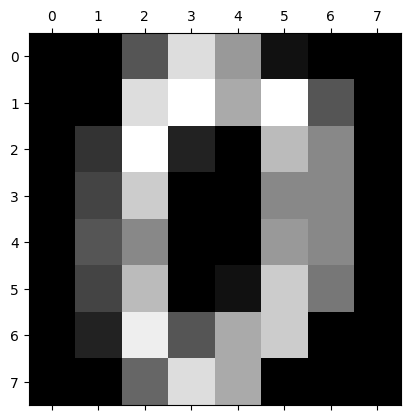

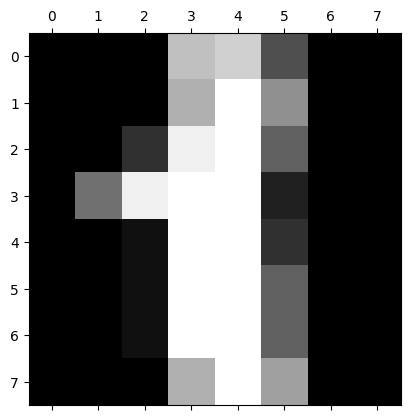

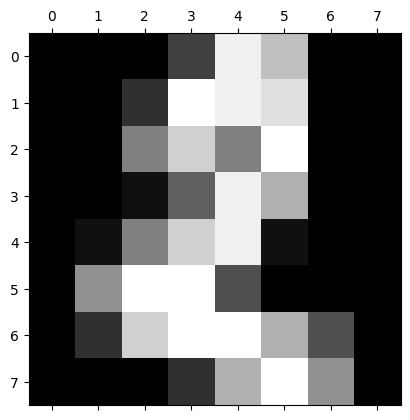

In [45]:
plt.gray()
for i in range(0, 3):
    plt.matshow(ld.images[i])

In [37]:
for i in range(0, 5):
    print(ld.target[i])

0
1
2
3
4


In [40]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(ld.data, ld.target, test_size=0.2)

In [50]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

1437
360
1437
360


In [51]:
from sklearn.linear_model import LogisticRegression

In [56]:
model = LogisticRegression(max_iter=len(X_train))
model.fit(X_train, y_train)

LogisticRegression(max_iter=1437)

In [57]:
model.score(X_test, y_test)

0.9527777777777777

In [68]:
model.predict([X_test[50]])

array([0])

In [69]:
y_test[50]

np.int64(0)

In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(X_test))
cm

array([[43,  0,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 31,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0, 31,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 32,  0,  1,  0,  2,  1,  0],
       [ 0,  0,  0,  0, 28,  0,  1,  0,  1,  0],
       [ 0,  0,  0,  1,  0, 30,  1,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 26,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 48,  0,  0],
       [ 0,  1,  0,  0,  1,  0,  1,  0, 34,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, 40]])

Text(50.722222222222214, 0.5, 'Predicted')

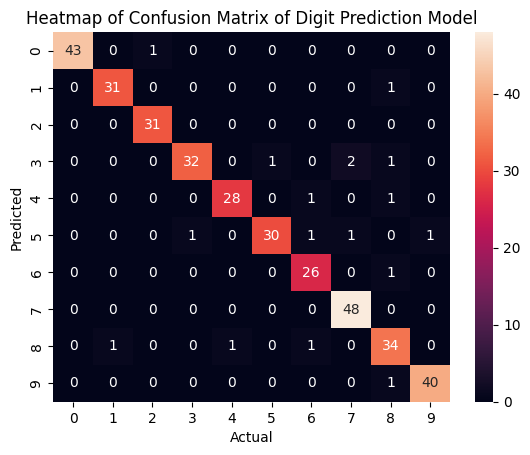

In [91]:
import seaborn as sn

sn.heatmap(cm, annot=True)
plt.title("Heatmap of Confusion Matrix of Digit Prediction Model")
plt.Figure(figsize=(1, 0.5))
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
print(iris.data.shape)

(150, 4)


In [5]:
print(iris.feature_names[0:4])
print(iris.data[0])
print(iris.target_names[0])
print(iris.target[0])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[5.1 3.5 1.4 0.2]
setosa
0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2
)

In [7]:
print(len(X_test))
print(len(y_test))
print(len(X_train))
print(len(y_train))

30
30
120
120


In [11]:
iris_model = LogisticRegression(max_iter = 500)
iris_model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [12]:
print(iris_model.predict(X_test))
print(y_test)

[1 1 0 0 2 2 2 0 1 0 2 2 2 0 0 0 0 1 0 2 2 0 0 1 2 0 1 1 2 1]
[1 1 0 0 2 2 2 0 1 0 2 2 2 0 0 0 0 1 0 2 2 0 0 1 2 0 1 1 2 1]


In [13]:
iris_model.score(X_test, y_test)

1.0

<Axes: >

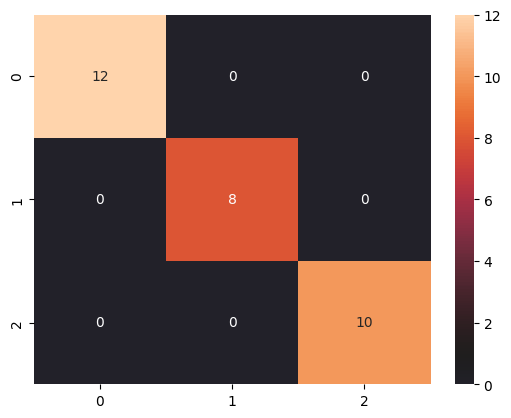

In [15]:
y_pred = iris_model.predict(X_test)
con_mat = confusion_matrix(y_test, y_pred)
sn.heatmap(con_mat, annot=True, center=0.9)

In [16]:
X_train.mean(axis=0)    # axis = 0 --> columnwise and axis = 1 --> rowwise

array([5.86      , 3.04416667, 3.79083333, 1.21166667])

In [161]:
import joblib
joblib.dump(iris_model, 'iris_model.pkl')

['iris_model.pkl']

In [162]:
X_test[0]

array([5. , 3.6, 1.4, 0.2])